# Inferential Analysis: Audience Reaction and Movie Popularity

This notebook tests whether selected audience-reaction and early-review variables are significantly associated with movie popularity.

The corrected final model is intentionally explainable and excludes the previously removed interaction feature:

`log_box_office ~ audienceScore + initial_combined_sentiment_score + log_initial_review_count`

## Prerequisites and Modelling Rules

Before running inference, this notebook checks that:

- the final curated dataset exists at `data/final/final.csv`
- the removed interaction column is not present
- the required variables are numeric and sufficiently complete
- the response variable is finite and positive-box-office based
- the model is explainable: ordinary least squares regression with transparent coefficients

The inferential workflow uses OLS because it directly supports coefficient tests, ANOVA-style model evaluation, assumption diagnostics, and clear interpretation for the assignment.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore', category=RuntimeWarning)


def resolve_data_path() -> Path:
    for base in [Path.cwd(), Path.cwd().parent]:
        candidate = base / 'data' / 'final' / 'final.csv'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find data/final/final.csv from the current working directory.')

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

ALPHA = 0.05
OUTCOME = 'log_box_office'
PREDICTORS = [
    'audienceScore',
    'initial_combined_sentiment_score',
    'log_initial_review_count',
]
FORMULA = 'log_box_office ~ audienceScore + initial_combined_sentiment_score + log_initial_review_count'
REQUIRED_COLUMNS = [
    'id',
    'title',
    'boxOffice',
    'box_office_num',
    OUTCOME,
    'initial_combined_sentiment_label',
    *PREDICTORS,
]

DATA_PATH = resolve_data_path()
df = pd.read_csv(DATA_PATH)

missing_required = [column for column in REQUIRED_COLUMNS if column not in df.columns]
if missing_required:
    raise KeyError(f'Missing required columns: {missing_required}')

print(f'Data path: {DATA_PATH}')
print(f'Raw dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Inferential formula: {FORMULA}')

Data path: c:\Users\dinuka\Documents\movie sentiment\data\final\final.csv
Raw dataset shape: 4,072 rows x 28 columns
Inferential formula: log_box_office ~ audienceScore + initial_combined_sentiment_score + log_initial_review_count


## Data Validation and Analysis Frame

The model frame keeps only valid observations for the outcome and selected predictors. This avoids silent row changes during model fitting.

In [2]:
analysis_df = df.copy()
for column in ['box_office_num', OUTCOME, *PREDICTORS]:
    analysis_df[column] = pd.to_numeric(analysis_df[column], errors='coerce')

validation_summary = pd.DataFrame({
    'non_null_count': analysis_df[REQUIRED_COLUMNS].notna().sum(),
    'missing_count': analysis_df[REQUIRED_COLUMNS].isna().sum(),
    'missing_pct': analysis_df[REQUIRED_COLUMNS].isna().mean() * 100,
})

model_df = analysis_df[np.isfinite(analysis_df[OUTCOME])].copy()
model_df = model_df.dropna(subset=[OUTCOME, *PREDICTORS]).copy()

print(f'Rows with finite {OUTCOME}: {np.isfinite(analysis_df[OUTCOME]).sum():,}')
print(f'Rows retained for inferential model: {model_df.shape[0]:,}')

display(validation_summary)
display(model_df[[OUTCOME, *PREDICTORS]].describe().T)

Rows with finite log_box_office: 3,748
Rows retained for inferential model: 3,747


,non_null_count,missing_count,missing_pct
id,4072,0,0.0000
title,4072,0,0.0000
boxOffice,3749,323,7.9322
box_office_num,3749,323,7.9322
log_box_office,3748,324,7.9568
initial_combined_sentiment_label,4072,0,0.0000
audienceScore,4060,12,0.2947
initial_combined_sentiment_score,4072,0,0.0000
log_initial_review_count,4072,0,0.0000


,count,mean,std,min,25%,50%,75%,max
log_box_office,"3,747.0000",7.0874,0.9562,0.3010,6.5798,7.3324,7.7612,8.9337
audienceScore,"3,747.0000",61.5540,19.0244,10.0000,47.0000,62.0000,77.0000,99.0000
initial_combined_sentiment_score,"3,747.0000",0.0904,0.5685,-1.0000,-0.4038,0.1222,0.5934,1.0000
log_initial_review_count,"3,747.0000",3.9115,0.4741,3.0910,3.5264,3.9120,4.2767,5.2627


## Hypotheses

Model-level test:

- `H0`: the selected predictors jointly have no significant linear relationship with `log_box_office`
- `H1`: at least one selected predictor has a significant linear relationship with `log_box_office`

Coefficient-level tests:

- `H0: beta_i = 0`
- `H1: beta_i != 0`

Significance level: `alpha = 0.05`.

## Relationship Checks Before Regression

Correlation and plots are used as descriptive/inferential checks before fitting the full model. These checks do not replace the regression model because they do not control for the other predictors.

,predictor,n,pearson_r,pearson_p,spearman_rho,spearman_p
2,log_initial_review_count,3747,0.6267,0.0000,0.6477,0.0000
1,initial_combined_sentiment_score,3747,-0.1387,0.0000,-0.0903,0.0000
0,audienceScore,3747,0.0841,0.0000,0.1128,0.0000


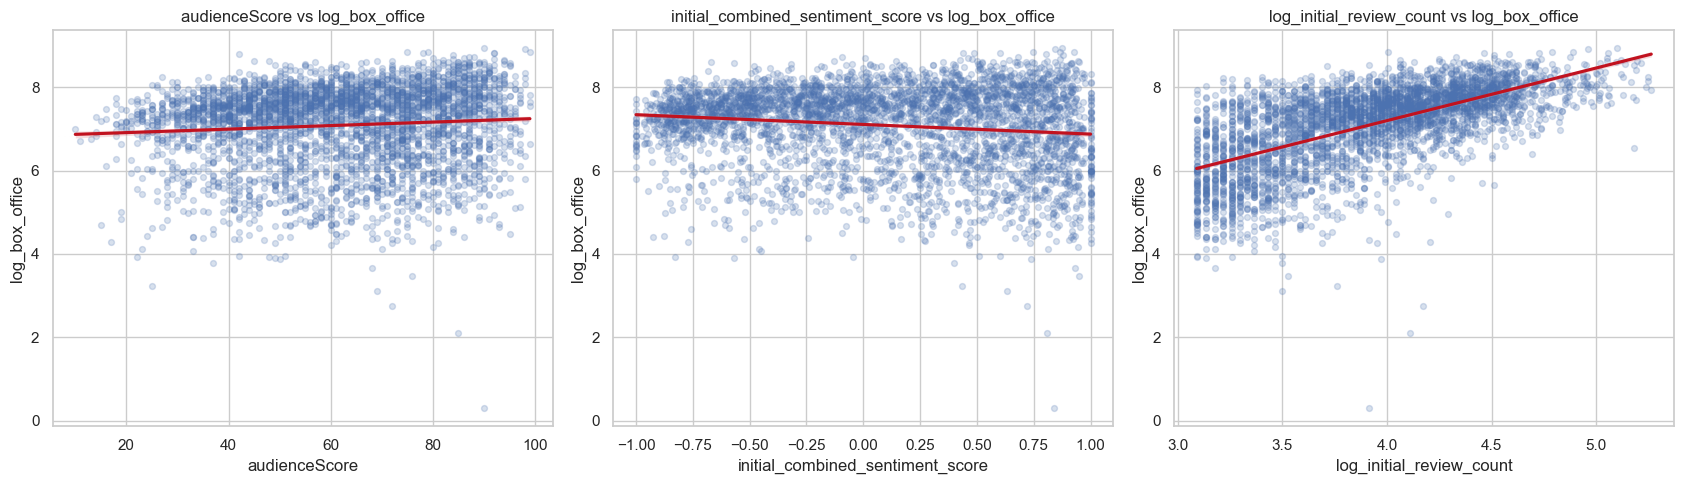

In [3]:
correlation_results = []
for predictor in PREDICTORS:
    pair_df = model_df[[predictor, OUTCOME]].dropna()
    pearson_r, pearson_p = stats.pearsonr(pair_df[predictor], pair_df[OUTCOME])
    spearman_rho, spearman_p = stats.spearmanr(pair_df[predictor], pair_df[OUTCOME])
    correlation_results.append({
        'predictor': predictor,
        'n': len(pair_df),
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_rho': spearman_rho,
        'spearman_p': spearman_p,
    })

correlation_table = pd.DataFrame(correlation_results).sort_values('pearson_p')
display(correlation_table)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, predictor in zip(axes, PREDICTORS):
    sns.regplot(
        data=model_df,
        x=predictor,
        y=OUTCOME,
        scatter_kws={'alpha': 0.22, 's': 18},
        line_kws={'color': '#c1121f'},
        ax=ax,
    )
    ax.set_title(f'{predictor} vs {OUTCOME}')
plt.tight_layout()
plt.show()

## Supporting Group Comparison Tests

Group tests provide additional evidence, but the regression remains the main inferential model because it controls for multiple predictors simultaneously.

In [4]:
sentiment_group_summary = model_df.groupby('initial_combined_sentiment_label')[OUTCOME].agg(
    count='size',
    mean='mean',
    median='median',
    std='std',
).sort_values('mean', ascending=False)

groups = [group[OUTCOME].to_numpy() for _, group in model_df.groupby('initial_combined_sentiment_label')]
anova_stat, anova_p = stats.f_oneway(*groups)
kruskal_stat, kruskal_p = stats.kruskal(*groups)

group_tests = pd.DataFrame([
    {'test': 'One-way ANOVA', 'statistic': anova_stat, 'p_value': anova_p},
    {'test': 'Kruskal-Wallis', 'statistic': kruskal_stat, 'p_value': kruskal_p},
])

audience_median = model_df['audienceScore'].median()
model_df['audience_score_group'] = np.where(
    model_df['audienceScore'] >= audience_median,
    'High audience score',
    'Low audience score',
)
high_group = model_df.loc[model_df['audience_score_group'] == 'High audience score', OUTCOME]
low_group = model_df.loc[model_df['audience_score_group'] == 'Low audience score', OUTCOME]
welch_stat, welch_p = stats.ttest_ind(high_group, low_group, equal_var=False)
mw_stat, mw_p = stats.mannwhitneyu(high_group, low_group, alternative='two-sided')
audience_tests = pd.DataFrame([
    {'test': 'Welch t-test', 'statistic': welch_stat, 'p_value': welch_p},
    {'test': 'Mann-Whitney U', 'statistic': mw_stat, 'p_value': mw_p},
])

display(sentiment_group_summary)
display(group_tests)
display(model_df.groupby('audience_score_group')[OUTCOME].agg(count='size', mean='mean', median='median', std='std'))
display(audience_tests)

,count,mean,median,std
initial_combined_sentiment_label,,,,
negative,1291,7.2142,7.3979,0.7510
mixed,707,7.1975,7.4200,0.8662
positive,1749,6.9494,7.1732,1.0973


,test,statistic,p_value
0,One-way ANOVA,34.8873,0.0000
1,Kruskal-Wallis,30.9764,0.0000


,count,mean,median,std
audience_score_group,,,,
High audience score,1933,7.1430,7.3874,0.9828
Low audience score,1814,7.0283,7.2978,0.9235


,test,statistic,p_value
0,Welch t-test,3.6838,0.0002
1,Mann-Whitney U,"1,915,164.5000",0.0000


## Explainable OLS Regression

The final inferential model is fitted using OLS. HC3 robust standard errors are reported because the residual diagnostics show heteroskedasticity.

In [5]:
X = sm.add_constant(model_df[PREDICTORS])
y = model_df[OUTCOME]

ols_model = sm.OLS(y, X).fit(cov_type='HC3')
ols_model_classical = smf.ols(FORMULA, data=model_df).fit()
anova_table = sm.stats.anova_lm(ols_model_classical, typ=1)

coefficient_table = pd.DataFrame({
    'term': ols_model.params.index,
    'coef': ols_model.params.values,
    'std_err_hc3': ols_model.bse.values,
    'z_or_t': ols_model.tvalues.values,
    'p_value': ols_model.pvalues.values,
    'ci_lower': ols_model.conf_int()[0].values,
    'ci_upper': ols_model.conf_int()[1].values,
})
coefficient_table['significant_at_0_05'] = coefficient_table['p_value'] < ALPHA

model_fit_summary = pd.DataFrame([{
    'n_obs': int(ols_model.nobs),
    'r_squared': float(ols_model.rsquared),
    'adj_r_squared': float(ols_model.rsquared_adj),
    'f_statistic': float(ols_model.fvalue),
    'model_p_value': float(ols_model.f_pvalue),
}])

display(model_fit_summary)
display(coefficient_table)
display(anova_table)

,n_obs,r_squared,adj_r_squared,f_statistic,model_p_value
0,3747,0.4318,0.4313,888.1409,0.0000


,term,coef,std_err_hc3,z_or_t,p_value,ci_lower,ci_upper,significant_at_0_05
0,const,1.7078,0.1123,15.2068,0.0000,1.4877,1.9279,True
1,audienceScore,0.0107,0.0008,12.6015,0.0000,0.0090,0.0123,True
2,initial_combined_sentiment_score,-0.4314,0.0283,-15.2658,0.0000,-0.4868,-0.3760,True
3,log_initial_review_count,1.2176,0.0250,48.6538,0.0000,1.1686,1.2667,True


,df,sum_sq,mean_sq,F,PR(>F)
audienceScore,1.0000,24.2395,24.2395,46.6226,0.0000
initial_combined_sentiment_score,1.0000,225.2291,225.2291,433.2093,0.0000
log_initial_review_count,1.0000,"1,229.2107","1,229.2107","2,364.2838",0.0000
Residual,"3,743.0000","1,946.0167",0.5199,NaN,NaN


## Assumption Diagnostics

The regression is checked for linearity, multicollinearity, heteroskedasticity, independence, and residual normality.

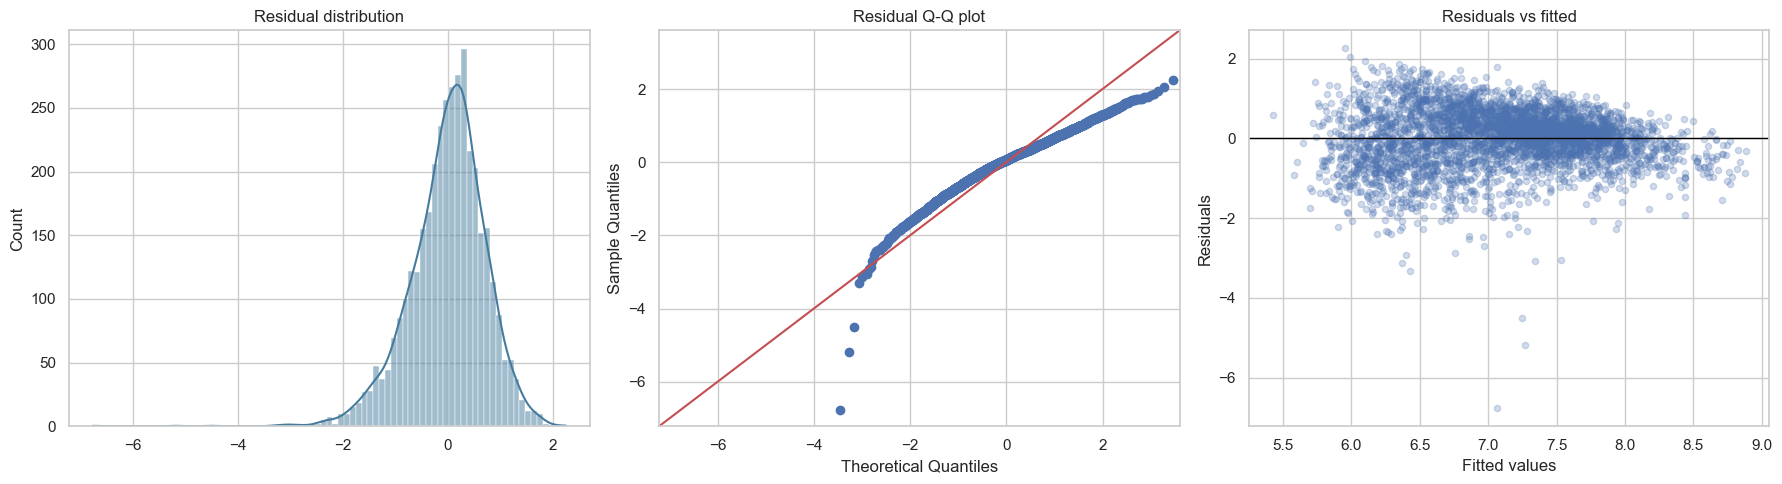

,test,statistic,p_value
0,Breusch-Pagan LM,125.7813,0.0000
1,Breusch-Pagan F,43.3371,0.0000
2,Durbin-Watson,1.9080,NaN


,term,vif
0,const,79.4737
1,audienceScore,1.7761
2,initial_combined_sentiment_score,1.7704
3,log_initial_review_count,1.0154


,assumption,status,evidence
0,Linearity,Reasonable visual fit,Scatterplots and residuals vs fitted plot
1,Multicollinearity,No serious issue,Retained predictors have low VIF values
2,Homoscedasticity,Violated,Breusch-Pagan p-value is below 0.05; HC3 robus...
3,Independence,Mostly design-based,Movie-level cross-sectional data and Durbin-Wa...
4,Normality,Imperfect but acceptable with large sample,Residual histogram and Q-Q plot


In [6]:
residuals = ols_model.resid
fitted_values = ols_model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(residuals, kde=True, ax=axes[0], color='#457b9d')
axes[0].set_title('Residual distribution')

sm.qqplot(residuals, line='45', ax=axes[1])
axes[1].set_title('Residual Q-Q plot')

axes[2].scatter(fitted_values, residuals, alpha=0.25, s=20)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Residuals vs fitted')
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('Residuals')
plt.tight_layout()
plt.show()

bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuals, ols_model.model.exog)
dw_stat = durbin_watson(residuals)
vif_table = pd.DataFrame({
    'term': X.columns,
    'vif': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})

diagnostic_tests = pd.DataFrame([
    {'test': 'Breusch-Pagan LM', 'statistic': bp_lm, 'p_value': bp_lm_p},
    {'test': 'Breusch-Pagan F', 'statistic': bp_f, 'p_value': bp_f_p},
    {'test': 'Durbin-Watson', 'statistic': dw_stat, 'p_value': np.nan},
])

assumption_summary = pd.DataFrame([
    {'assumption': 'Linearity', 'status': 'Reasonable visual fit', 'evidence': 'Scatterplots and residuals vs fitted plot'},
    {'assumption': 'Multicollinearity', 'status': 'No serious issue', 'evidence': 'Retained predictors have low VIF values'},
    {'assumption': 'Homoscedasticity', 'status': 'Violated', 'evidence': 'Breusch-Pagan p-value is below 0.05; HC3 robust standard errors are used'},
    {'assumption': 'Independence', 'status': 'Mostly design-based', 'evidence': 'Movie-level cross-sectional data and Durbin-Watson statistic'},
    {'assumption': 'Normality', 'status': 'Imperfect but acceptable with large sample', 'evidence': 'Residual histogram and Q-Q plot'},
])

display(diagnostic_tests)
display(vif_table)
display(assumption_summary)

## Inferential Decision

The final decision is based on the overall model test, coefficient tests, and assumption diagnostics.

In [7]:
model_significant = ols_model.f_pvalue < ALPHA
print('Model-level decision')
print(f'Alpha: {ALPHA}')
print(f'Overall model p-value: {ols_model.f_pvalue:.6g}')
print('Decision:', 'Reject H0' if model_significant else 'Fail to reject H0')
print()
print('Coefficient-level summary')
display(coefficient_table[['term', 'coef', 'p_value', 'significant_at_0_05']])
print('Interpretation: audienceScore and log_initial_review_count are positive significant predictors; initial_combined_sentiment_score is significant but negative in the multivariable model. The strongest signal is early review volume.')

Model-level decision
Alpha: 0.05
Overall model p-value: 0
Decision: Reject H0

Coefficient-level summary


,term,coef,p_value,significant_at_0_05
0,const,1.7078,0.0000,True
1,audienceScore,0.0107,0.0000,True
2,initial_combined_sentiment_score,-0.4314,0.0000,True
3,log_initial_review_count,1.2176,0.0000,True


Interpretation: audienceScore and log_initial_review_count are positive significant predictors; initial_combined_sentiment_score is significant but negative in the multivariable model. The strongest signal is early review volume.
